Importing Libraries

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Loading Dataset

In [26]:
# Load dataset
df = pd.read_csv("customer_behavior.csv")

# Show first 5 rows
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


Checking Dataset

In [27]:
# Dataset shape
print(df.shape)

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

# Check missing values
print(df.isnull().sum())

# Check duplicate values
print(df.duplicated().sum())

(250000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB
None
        Custo

Data Cleaning

In [28]:
# Check missing values

print(df.isnull().sum())

# Remove duplicate rows

df.drop_duplicates(inplace=True)

# Remove missing values

df.dropna(inplace=True)

# Convert Purchase Date into datetime format

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Verify dataset

print(df.info())

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 202404 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            202404 non-null  int64         
 1   Purchase Date          202404 non-null  datetime64[ns]
 2   Product Category       202404 non-null  object        
 3   Product Price          202404 non-null  int64         
 4   Quantity               202404 non-null  int64         
 5   Total Purchase Amount  202404 non-null  int64        

1. Identify Customer Segments

Creating RFM Table

In [29]:
# Find latest purchase date
latest_date = df['Purchase Date'].max()

# Create RFM values
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (latest_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Display first rows
print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
1                 57          1      3491
2                298          2      7029
3                 88          7     18172
4                585          1      3154
5                170          6     10239


Normalizing Data

In [30]:
# Normalize RFM values

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

ELBOW METHOD

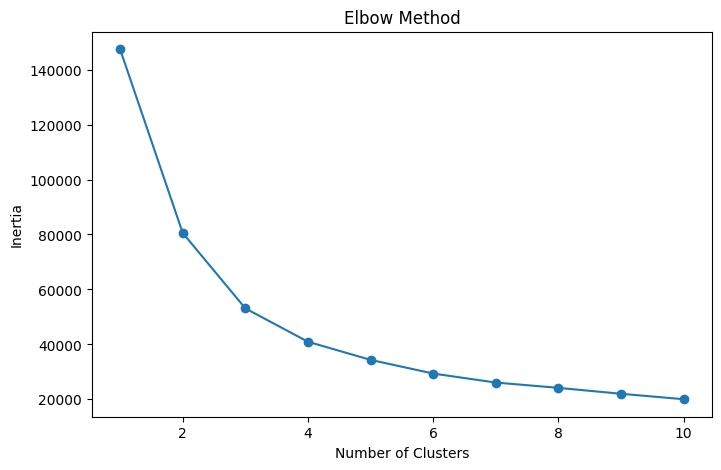

In [31]:
inertia = []

for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

Apply K-Means Clustering

In [32]:
# Create KMeans model
kmeans = KMeans(n_clusters=4, random_state=42)

# Predict clusters
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Show first rows
print(rfm.head())

             Recency  Frequency  Monetary  Cluster
Customer ID                                       
1                 57          1      3491        0
2                298          2      7029        0
3                 88          7     18172        1
4                585          1      3154        2
5                170          6     10239        3


Profile Each Segment

In [33]:
# Analyze average values of each cluster

segment_profile = rfm.groupby('Cluster').mean()

print(segment_profile)

            Recency  Frequency      Monetary
Cluster                                     
0        220.750510   2.709478   6733.970362
1        155.475160   7.296649  21289.003781
2        796.187857   2.313250   6119.750379
3        212.523495   4.826499  13190.814244


Segment Visualization

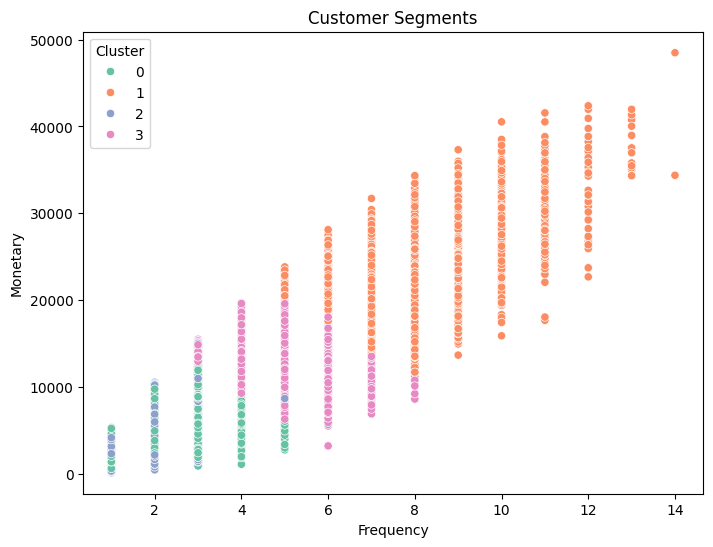

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster'],
    palette='Set2'
)

plt.title("Customer Segments")

plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

Monthly Purchase Trend Analysis

Monthly Purchase Trend Analysis

2. Analyzing Customer Transactions

Monthly Sales Trend Analysis

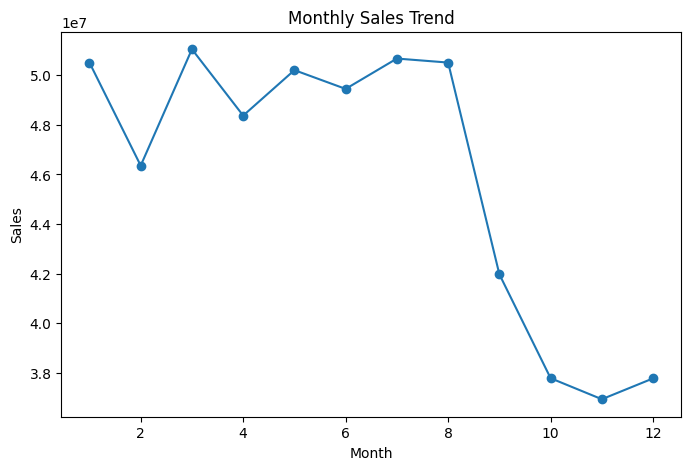

In [35]:
monthly_sales = df.groupby(
    df['Purchase Date'].dt.month
)['Total Purchase Amount'].sum()

plt.figure(figsize=(8,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

Product Category Sales Analysis

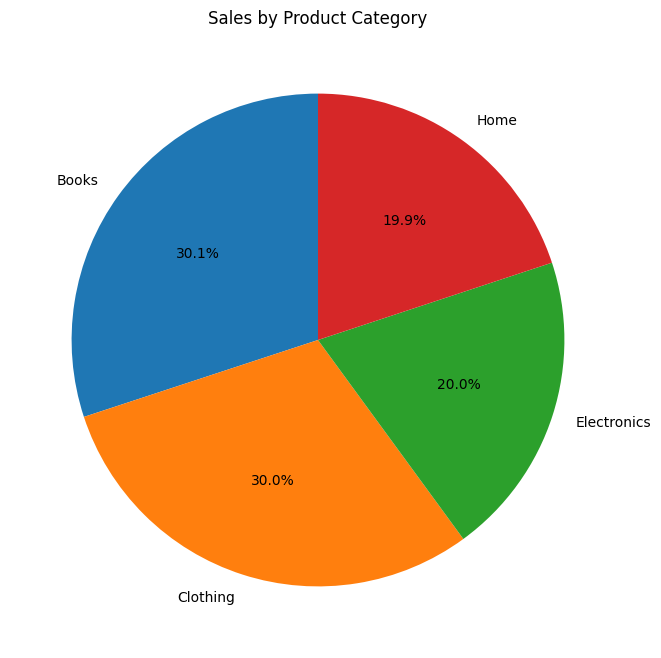

In [36]:
plt.figure(figsize=(8,8))

sales_data = df.groupby('Product Category')[
    'Total Purchase Amount'
].sum()

plt.pie(
    sales_data,
    labels=sales_data.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sales by Product Category")

plt.show()

Quantity Sold by Product Category

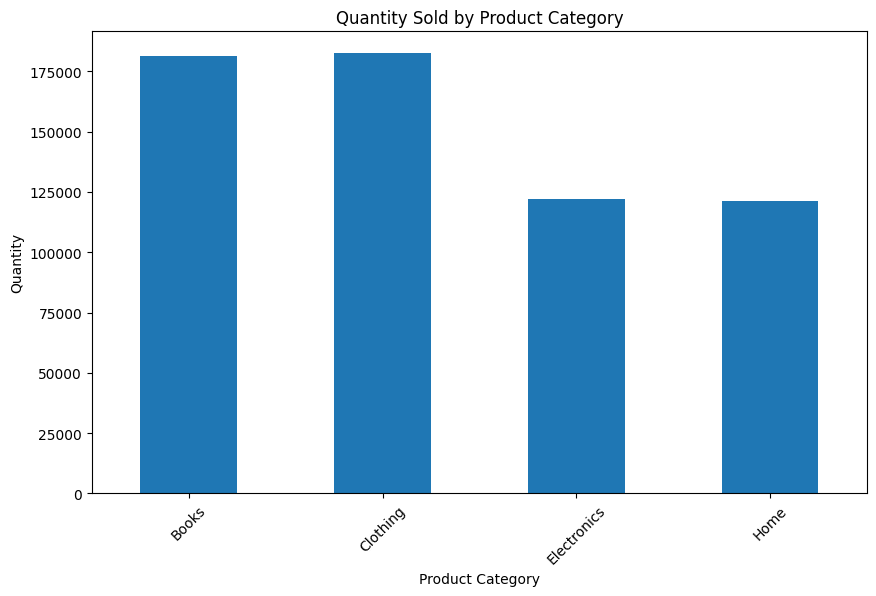

In [37]:
category_quantity = df.groupby('Product Category')[
    'Quantity'
].sum()

plt.figure(figsize=(10,6))

category_quantity.plot(kind='bar')

plt.title("Quantity Sold by Product Category")

plt.xlabel("Product Category")
plt.ylabel("Quantity")

plt.xticks(rotation=45)

plt.show()

Total Sales Analysis

In [38]:
# Total sales generated

total_sales = df['Total Purchase Amount'].sum()

print("Total Sales:", total_sales)

Total Sales: 551577377


ESTIMATED PROFIT ANALYSIS


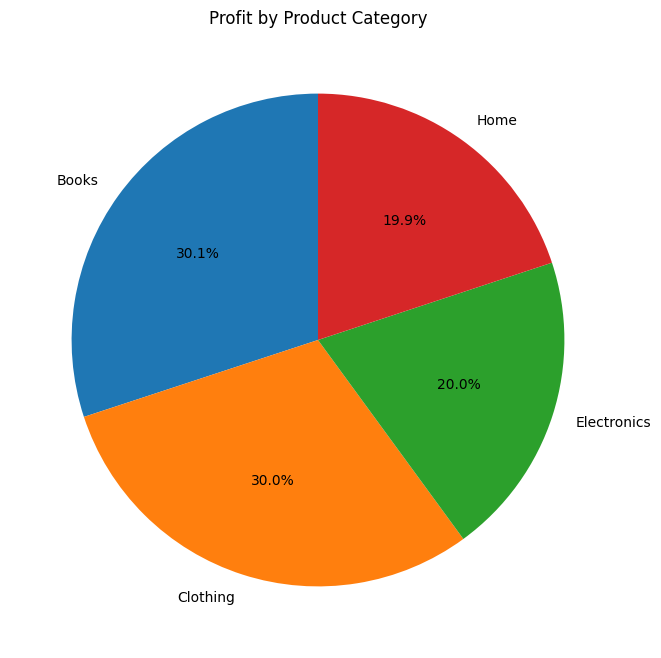

In [39]:
# Create Estimated Profit Column
df['Profit'] = df['Total Purchase Amount'] * 0.20

profit_data = df.groupby('Product Category')[
    'Profit'
].sum()

plt.figure(figsize=(8,8))

plt.pie(
    profit_data,
    labels=profit_data.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Profit by Product Category")

plt.show()

3. Analyze Customer Behavior

TOP CUSTOMERS BY QUANTITY

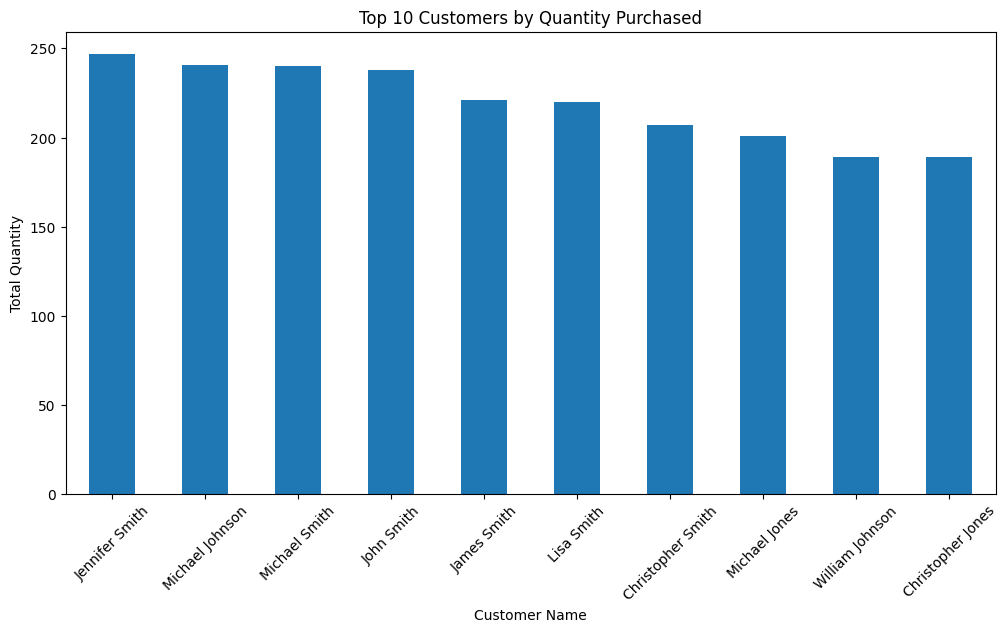

In [40]:
quantity_data = df.groupby('Customer Name')[
    'Quantity'
].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

quantity_data.plot(kind='bar')

plt.title("Top 10 Customers by Quantity Purchased")

plt.xlabel("Customer Name")
plt.ylabel("Total Quantity")

plt.xticks(rotation=45)

plt.show()

Gender-wise Purchase Analysis

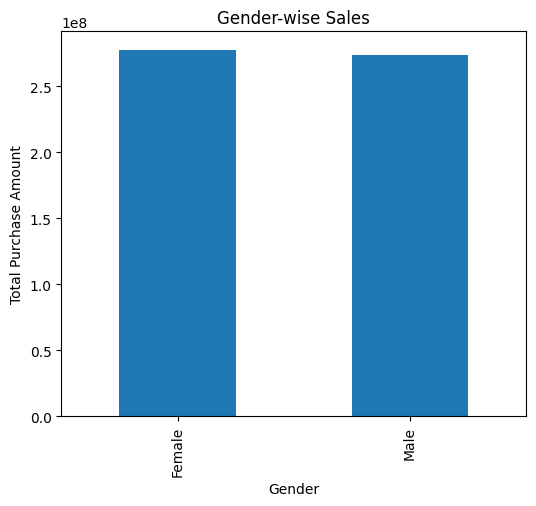

In [41]:
gender_sales = df.groupby('Gender')[
    'Total Purchase Amount'
].sum()

plt.figure(figsize=(6,5))

gender_sales.plot(kind='bar')

plt.title("Gender-wise Sales")
plt.ylabel("Total Purchase Amount")

plt.show()

Product Preference Analysis

In [42]:
# Most purchased product categories

product_preference = df['Product Category'].value_counts()

print(product_preference)

Product Category
Clothing       60729
Books          60595
Electronics    40657
Home           40423
Name: count, dtype: int64


4. Identify Purchase Patterns

Product Category Pie Chart

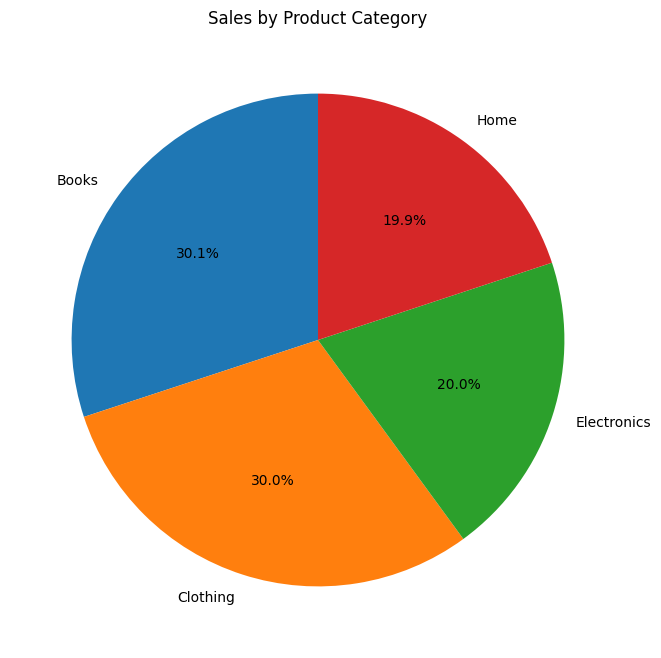

In [43]:
plt.figure(figsize=(8,8))

sales_data = df.groupby('Product Category')[
    'Total Purchase Amount'
].sum()

plt.pie(
    sales_data,
    labels=sales_data.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sales by Product Category")

plt.show()

Quantity by Product Category

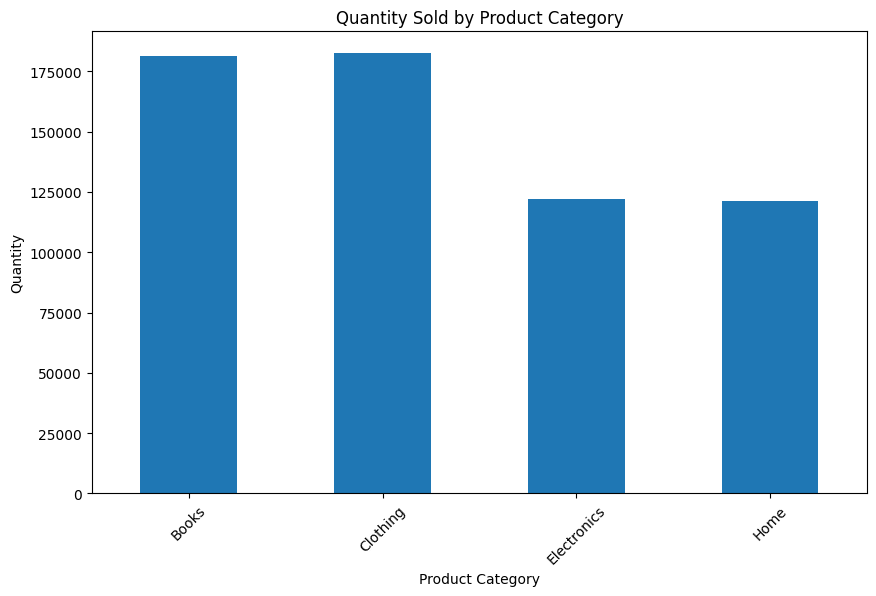

In [44]:
category_quantity = df.groupby('Product Category')[
    'Quantity'
].sum()

plt.figure(figsize=(10,6))

category_quantity.plot(kind='bar')

plt.title("Quantity Sold by Product Category")

plt.xlabel("Product Category")
plt.ylabel("Quantity")

plt.xticks(rotation=45)

plt.show()

5. Identifying Churn Risks

Churn Analysis

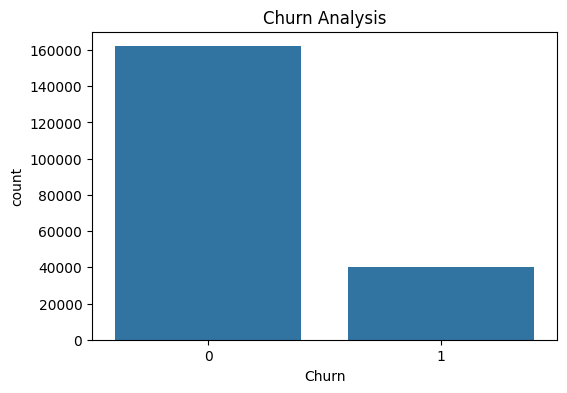

In [45]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Churn Analysis")

plt.show()

Churn vs Purchase Amount

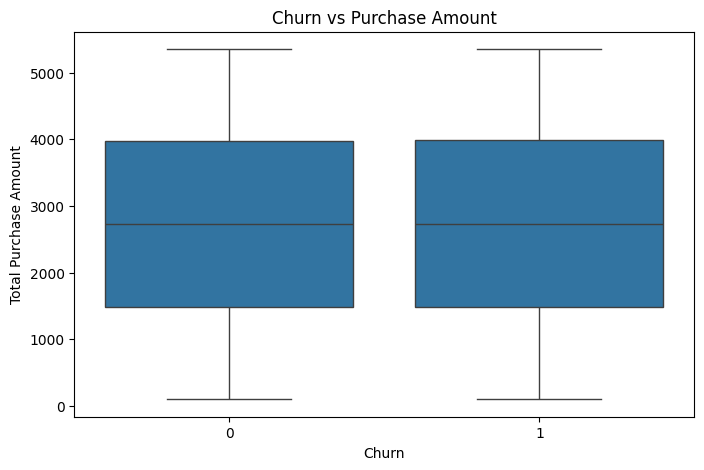

In [46]:
# Churn vs spending behavior

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Total Purchase Amount',
    data=df
)

plt.title("Churn vs Purchase Amount")

plt.show()

Retention / Churn Trend

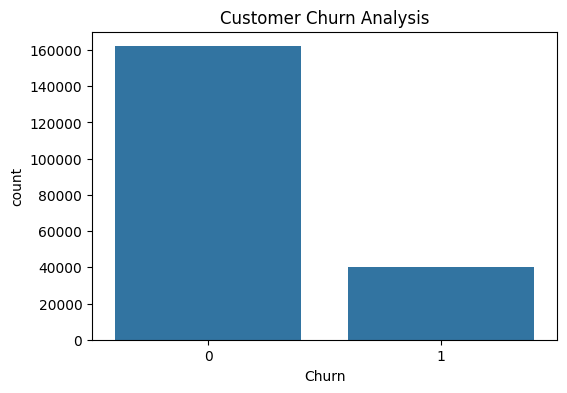

In [47]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn Analysis")

plt.show()

Providing 5 Actionable Recommendations for Alfido Tech

In [48]:
recommendations = [
    "Reward loyal customers with loyalty points and discounts.",
    
    "Re-engage churn-risk customers using personalized offers.",
    
    "Promote high-performing product categories through targeted marketing.",
    
    "Use customer behavior data for personalized product recommendations.",
    
    "Launch retention campaigns such as memberships and festival offers."
]

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

1. Reward loyal customers with loyalty points and discounts.
2. Re-engage churn-risk customers using personalized offers.
3. Promote high-performing product categories through targeted marketing.
4. Use customer behavior data for personalized product recommendations.
5. Launch retention campaigns such as memberships and festival offers.


CORRELATION HEATMAP

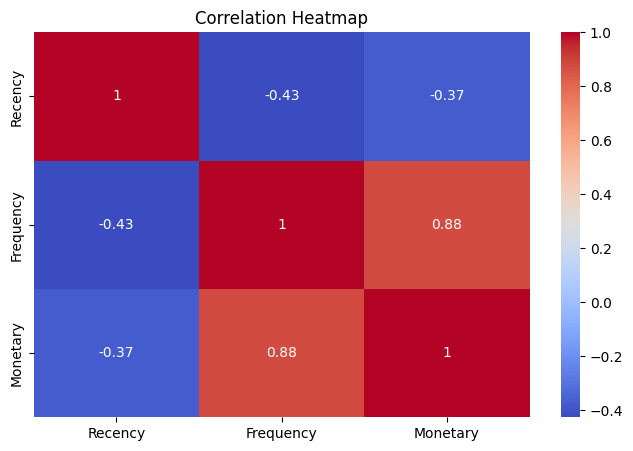

In [49]:
plt.figure(figsize=(8,5))

sns.heatmap(
    rfm[['Recency', 'Frequency', 'Monetary']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [50]:
# =========================================================
# CREATE CLEANED CSV FILE
# =========================================================

# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove missing values
df.dropna(inplace=True)

# Convert Purchase Date into datetime format
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Save cleaned dataset into new CSV file
df.to_csv("clean_customer_behavior.csv", index=False)

print("Cleaned CSV file created successfully!")

Cleaned CSV file created successfully!
